#**EM ALGORITHM**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)     # Giving a unique identifier to all Random Choices made

Text(0.5, 1.0, 'Gaussian Distribution with Mean 0 and sigma 1')

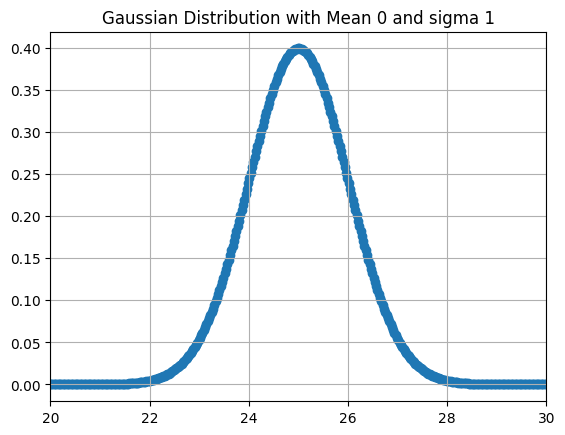

In [ ]:
def gaussian(mu,sigma,x):
    s = 1/(sigma * (2*np.pi)**0.5)*np.exp(-(x - mu)**2/(2*sigma**2))
    return s
X = np.linspace(0,50,1900)

plt.scatter(X,gaussian(25,1,X))
plt.grid()
plt.xlim(20,30)
plt.title('Gaussian Distribution with Mean 0 and sigma 1')

In [ ]:
def gen():
    p = []
    global original_centers
    original_centers = []
    for i in np.random.randint(0,50,3):
        k = np.random.normal(i, 1, 200)
        original_centers.append(i)
        p.append(np.random.choice(k,40).tolist())
    t = np.array(p).flatten()
    np.random.shuffle(t)
    return t

## 🧠 EM Algorithm for Gaussian Mixture Models (GMM)

### 🔁 The Iterative Process

Repeat until convergence:

$$
|\mathcal{L}{new} - \mathcal{L}{old}| < \epsilon
$$

where $\mathcal{L}$ is the Likelihood
---

### 🔵 Step 1: E-Step (Expectation)

Calculate the responsibilities ($\gamma_{ik}$), which represent the probability that data point $x_i$ belongs to cluster $k$.

**Compute Likelihood:**
$$
p_{ik} = \mathcal{N}(x_i \mid \mu_k, \sigma_k^2)
$$

**Apply Weights:**
$$
w_{ik} = \pi_k \cdot p_{ik}
$$

**Normalize:**
$$
\gamma_{ik} = \frac{w_{ik}}{\sum_{j=1}^{K} w_{ij}}
$$

**Array Shape:**

* $\gamma$ is an $(N \times K)$ matrix
* Rows ($i$) = Data points
* Columns ($k$) = Gaussian components

---

### 🔴 Step 2: M-Step (Maximization)

Update the parameters $(\mu, \sigma^2, \pi)$ using the weighted values from the E-step.

**Effective Points per Cluster:**
$$
N_k = \sum_{i=1}^{N} \gamma_{ik}
$$

**Update Mean:**
$$
\mu_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_{ik} \cdot x_i
$$

**Update Variance:**
$$
\sigma_k^2 = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_{ik} (x_i - \mu_k)^2
$$

**Update Mixing Weight:**
$$
\pi_k = \frac{N_k}{N}
$$

---

### 📈 Step 3: Log-Likelihood (Convergence Check)

To verify the algorithm is learning, calculate the total log-likelihood after every iteration. It must increase monotonically.

$$
\mathcal{L}(\theta) = \sum_{i=1}^{N} \ln \left( \sum_{k=1}^{K} \pi_k \mathcal{N}(x_i \mid \mu_k, \sigma_k^2) \right)
$$


In [ ]:
# Implementing the EM Algorithm for K = 3

def E_step(pie_initial,mu_initial,data,K):
    w = np.empty((len(data),K))

    for i in range(len(data)):
        for j in range(K):
            w[i,j] = pie_initial[j] * gaussian(mu_initial[j],1,data[i])
    colsum = np.sum(w,axis = 1) + 1e-10
    for i in range(len(data)):
        w[i,:] = w[i,:]/colsum[i]
    return w

In [ ]:
def M_step(w,mu,pie,K,data):
    N_k = np.sum(w,axis = 0)
    sum = 0
    for i in range(K):
        mu[i] = np.sum(w[:,i] * data) / N_k[i]
        pie[i] = N_k[i]/len(data)

    return mu,pie

In [ ]:
def log_likelihood(pie,data,K,w,mu):

    likelihood = 0.0

    for i in range(len(data)):
        sum = 0.0

        for j in range(K):
            sum = sum + pie[j] * gaussian(mu[j],1,data[i])

        likelihood = likelihood + np.log(sum + 1e-10)

    return likelihood


In [ ]:
def em_algorithm(tol):

    data = gen()
    a = 0
    iterations = 0

    K = 3
    mu_initial = [10,30,50]        # Initializing in such a way that it covers and converges to mean of all clusters in range[0,50]
    pie_initial = [1/K for i in range(K)]

    while(True):
        iterations += 1
        weight = E_step(pie_initial,mu_initial,data,K)

        likelihood = log_likelihood(pie_initial,data,K,weight,mu_initial)
        print(f"Log-Likelihood:{-likelihood},Mean Values for the Distributions: {mu_initial}")    # Negative Log-likelihood will decrease

        mu_initial,pie_initial = M_step(weight,mu_initial,pie_initial,K,data)



        if np.abs(likelihood - a) < tol or iterations > 1000:
            return mu_initial
            break
        a = likelihood



In [ ]:
mu_calc = em_algorithm(0.00001)

Log-Likelihood:1608.8152661983484,Mean Values for the Distributions: [10, 30, 50]
Log-Likelihood:1133.7149479595735,Mean Values for the Distributions: [np.float64(14.348678800131575), np.float64(28.329124482236917), np.float64(39.43047856940514)]
Log-Likelihood:1023.361263225644,Mean Values for the Distributions: [np.float64(14.42226049528986), np.float64(27.812310114462175), np.float64(38.545750792793974)]
Log-Likelihood:306.0682797370355,Mean Values for the Distributions: [np.float64(14.422260495946826), np.float64(27.812267586151588), np.float64(38.09810758915365)]
Log-Likelihood:302.07113198648415,Mean Values for the Distributions: [np.float64(14.422260495946826), np.float64(27.812267260157125), np.float64(38.02839061790273)]
Log-Likelihood:302.0711319801284,Mean Values for the Distributions: [np.float64(14.422260495946826), np.float64(27.812267260157117), np.float64(38.02839061774132)]


In [ ]:
print(f"True Mean Values of the distribution : {np.sort(original_centers)} \n Calculated Mean Values of the Distribution: {np.sort(mu_calc)}  \n Mean squared Error : {np.mean((np.sort(original_centers) - np.sort(mu_calc))**2)}")

True Mean Values of the distribution : [14 28 38] 
 Calculated Mean Values of the Distribution: [14.4222605  27.81226726 38.02839062]  
 Mean squared Error : 0.07145117840730303


# **NEURAL NETWORK**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_digits
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
df = load_digits(as_frame=True)
data = df['data']
target = df['target']
data.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(data,target,train_size = .75 , test_size = .25 , random_state = 42)

In [ ]:
model = MLPClassifier(hidden_layer_sizes=(100,50),
                      activation = 'tanh',
                      solver = 'adam' ,
                      batch_size= 32 ,
                      learning_rate = "adaptive",
                      shuffle = True,
                      validation_fraction = 0.2 ,
                      max_iter= 100,
                      verbose = True,
                      early_stopping = True)

In [ ]:
model.fit(xtrain,ytrain)

Iteration 1, loss = 1.70928853
Validation score: 0.751852
Iteration 2, loss = 0.75990812
Validation score: 0.870370
Iteration 3, loss = 0.44649777
Validation score: 0.907407
Iteration 4, loss = 0.30153152
Validation score: 0.940741
Iteration 5, loss = 0.21645538
Validation score: 0.940741
Iteration 6, loss = 0.16814107
Validation score: 0.940741
Iteration 7, loss = 0.13123066
Validation score: 0.951852
Iteration 8, loss = 0.10242289
Validation score: 0.962963
Iteration 9, loss = 0.08286846
Validation score: 0.959259
Iteration 10, loss = 0.06819199
Validation score: 0.970370
Iteration 11, loss = 0.05703333
Validation score: 0.962963
Iteration 12, loss = 0.04913565
Validation score: 0.966667
Iteration 13, loss = 0.04373282
Validation score: 0.970370
Iteration 14, loss = 0.03609073
Validation score: 0.966667
Iteration 15, loss = 0.03009133
Validation score: 0.962963
Iteration 16, loss = 0.02598550
Validation score: 0.970370
Iteration 17, loss = 0.02231224
Validation score: 0.966667
Iterat

MLPClassifier(activation='tanh', batch_size=32, early_stopping=True,
              hidden_layer_sizes=(100, 50), learning_rate='adaptive',
              max_iter=100, validation_fraction=0.2, verbose=True)

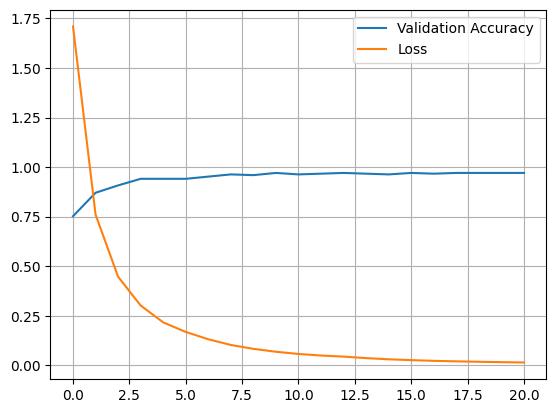

In [ ]:
plt.plot(model.validation_scores_,label = 'Validation Accuracy')
plt.plot(model.loss_curve_,label = "Loss")
plt.legend()
plt.grid()

In [ ]:
print(f"The accuracy for the model is {round(model.score(xtest,ytest),4) * 100}%")

The accuracy for the model is 96.67%


In [ ]:
model2 = MLPClassifier(hidden_layer_sizes=(100,50),
                      activation = 'tanh',
                      solver = 'adam' ,
                      learning_rate = "adaptive",
                      shuffle = True,
                      batch_size= 32 ,
                      validation_fraction = 0.2 ,
                      max_iter= 100,
                      verbose = True,
                      early_stopping = True,
                      alpha = .2  # Stength of L2 Regularization
)

In [ ]:
model2.fit(xtrain,ytrain)

Iteration 1, loss = 2.11904385
Validation score: 0.788889
Iteration 2, loss = 1.15935631
Validation score: 0.914815
Iteration 3, loss = 0.85680080
Validation score: 0.944444
Iteration 4, loss = 0.72061684
Validation score: 0.951852
Iteration 5, loss = 0.64347540
Validation score: 0.951852
Iteration 6, loss = 0.58475410
Validation score: 0.959259
Iteration 7, loss = 0.54454289
Validation score: 0.959259
Iteration 8, loss = 0.51305253
Validation score: 0.974074
Iteration 9, loss = 0.48951305
Validation score: 0.977778
Iteration 10, loss = 0.46623906
Validation score: 0.974074
Iteration 11, loss = 0.44652586
Validation score: 0.977778
Iteration 12, loss = 0.42733463
Validation score: 0.981481
Iteration 13, loss = 0.41212204
Validation score: 0.981481
Iteration 14, loss = 0.39678923
Validation score: 0.981481
Iteration 15, loss = 0.38264754
Validation score: 0.981481
Iteration 16, loss = 0.36999017
Validation score: 0.977778
Iteration 17, loss = 0.35652252
Validation score: 0.981481
Iterat

MLPClassifier(activation='tanh', alpha=0.2, batch_size=32, early_stopping=True,
              hidden_layer_sizes=(100, 50), learning_rate='adaptive',
              max_iter=100, validation_fraction=0.2, verbose=True)

In [ ]:
print(f"The accuracy for the model is {round(model2.score(xtest,ytest),4) * 100}%")

The accuracy for the model is 97.78%


# Observation

*Increasing the strength of L2 Regularization to >1 or decreasing it below -1 causes decrease in Validation_accuracy or increase in loss , hence the optimum value lies near 0* .

Text(0.5, 0, 'Epochs(or Iterations)')

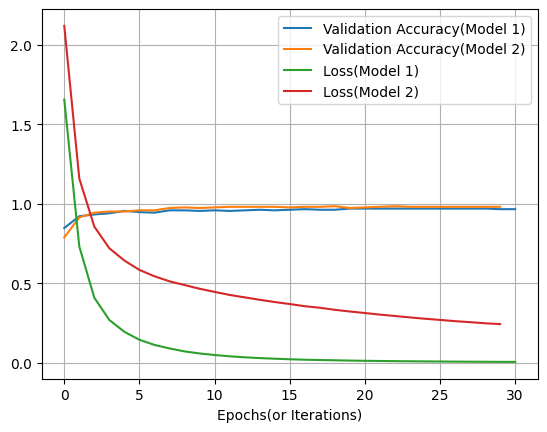

In [ ]:
plt.plot(model.validation_scores_,label = 'Validation Accuracy(Model 1)')
plt.plot(model2.validation_scores_,label = 'Validation Accuracy(Model 2)')
plt.plot(model.loss_curve_,label = 'Loss(Model 1)')
plt.plot(model2.loss_curve_,label = 'Loss(Model 2)')
plt.legend()
plt.grid()
plt.xlabel("Epochs(or Iterations)")

#L2 Regularization increases the PENALTY which causes the increase in loss for the Model2

<Axes: >

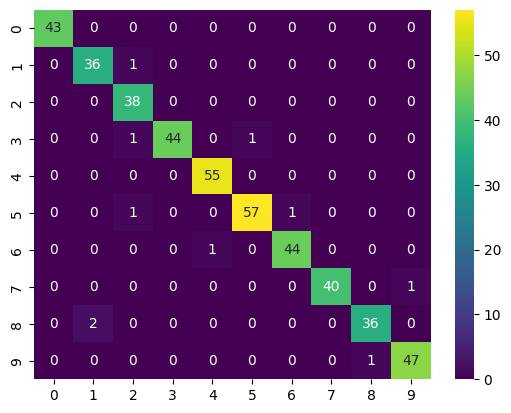

In [ ]:
cm = confusion_matrix(ytest,model.predict(xtest))
sns.heatmap(cm,cmap = 'viridis',annot = True)

<Axes: >

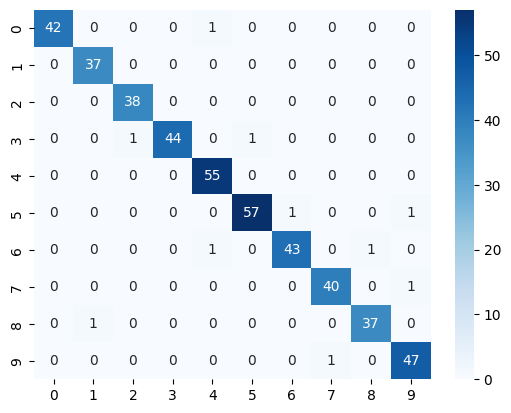

In [ ]:
cm = confusion_matrix(ytest,model2.predict(xtest))
sns.heatmap(cm,cmap = 'Blues',annot = True)

# **Support Vector Machine**

In [ ]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

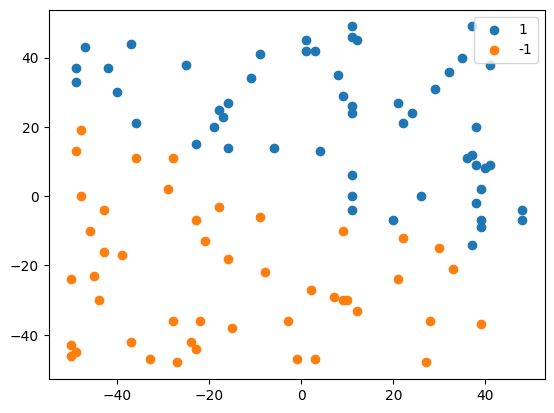

In [ ]:
x_s , x_e = -50 , 50  # Lower and upper Bounds

w1,w2,bias = 2.0 , 4.0 , -1.0  # Guessing a Hyperplane based on which generating the points

np.random.seed(42)
data = np.random.randint(x_s,x_e,(100,2))  # Generating the Random Data Points
y = np.array([1 if (w1 * i[0] + w2 * i[1] + bias)>0 else -1 for i in data])
plt.scatter(data[np.where(y==1)[0],0],data[np.where(y==1)[0],1],label = "1")
plt.scatter(data[np.where(y==-1)[0],0],data[np.where(y==-1)[0],1],label = "-1")
plt.legend()

In [ ]:
model = SVC(kernel="linear",verbose=True)
model.fit(data,y)

[LibSVM]

SVC(kernel='linear', verbose=True)

The width of the margin is 2.26627943623017


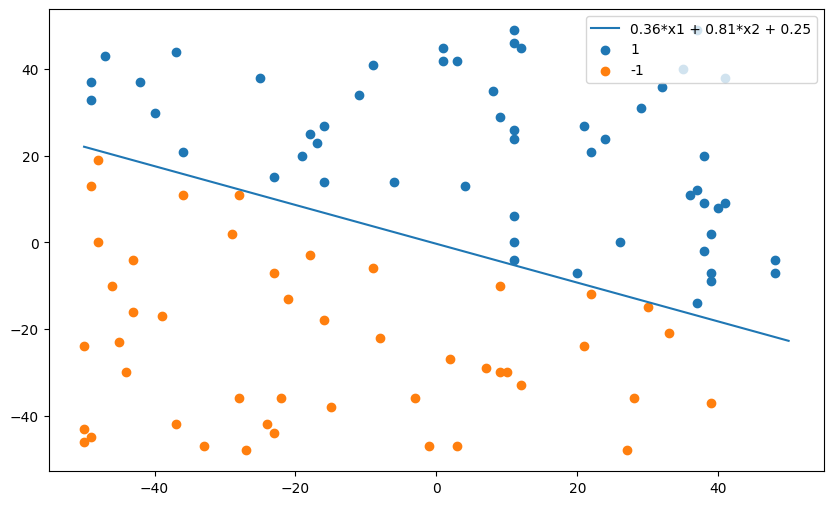

In [ ]:
weights = model.coef_
bias = model.intercept_
plt.figure(figsize= (10,6))
plt.plot(np.linspace(x_s,x_e,200),-(weights[:,0]*np.linspace(x_s,x_e,200) + bias)/weights[:,1],
         label=f"{round(weights[:,0][0],2)}*x1 + {round(weights[:,1][0],2)}*x2 + {round(bias[0],2)}")
plt.scatter(data[np.where(y==1)[0],0],data[np.where(y==1)[0],1],label = "1")
plt.scatter(data[np.where(y==-1)[0],0],data[np.where(y==-1)[0],1],label = "-1")
plt.legend()

print(f"The width of the margin is {2/np.linalg.norm(weights[0])}")

**The Equation for the Decision Boundary is** :
$$0.36 x_1 + 0.81 x_2 + 0.25 = 0$$

In [ ]:
data,target = load_iris(as_frame = True)['data'],load_iris(as_frame = True)['target']
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
xtrain , xtest , ytrain , ytest = train_test_split(data,target,train_size = .8 , test_size = .2 , random_state = 42 , shuffle = True)

In [ ]:
model_new = SVC(kernel="linear",degree=2).fit(xtrain,ytrain).score(xtest,ytest)
model_new2 = SVC(kernel="linear",degree=3).fit(xtrain,ytrain).score(xtest,ytest)
model_new_rbf = SVC(kernel="rbf",C = 0.1 , gamma = 0.1 , verbose = True).fit(xtrain,ytrain).score(xtest,ytest)
model_new_rbf2 = SVC(kernel="rbf",C = 1 , gamma = 0.1 , verbose = True).fit(xtrain,ytrain).score(xtest,ytest)
model_new_rbf3 = SVC(kernel="rbf",C = 10 , gamma = 0.1 , verbose = True).fit(xtrain,ytrain).score(xtest,ytest)

[LibSVM][LibSVM][LibSVM]

In [ ]:
print(f"Linear (degree 2) Score: {model_new}")
print(f"Linear (degree 3) Score: {model_new2}")
print(f"RBF (C=0.1, gamma=0.1) Score: {model_new_rbf}")
print(f"RBF (C=1.0, gamma=0.1) Score: {model_new_rbf2}")
print(f"RBF (C=10.0, gamma=0.1) Score: {model_new_rbf3}")


Linear (degree 2) Score: 1.0
Linear (degree 3) Score: 1.0
RBF (C=0.1, gamma=0.1) Score: 0.9666666666666667
RBF (C=1.0, gamma=0.1) Score: 1.0
RBF (C=10.0, gamma=0.1) Score: 1.0
